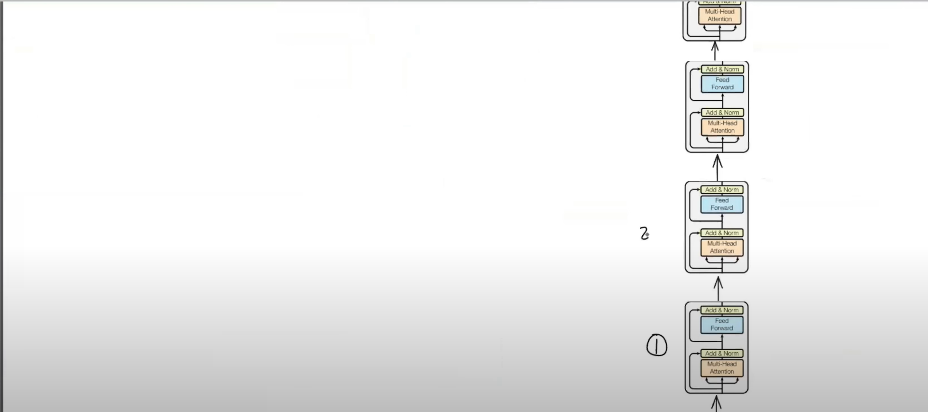

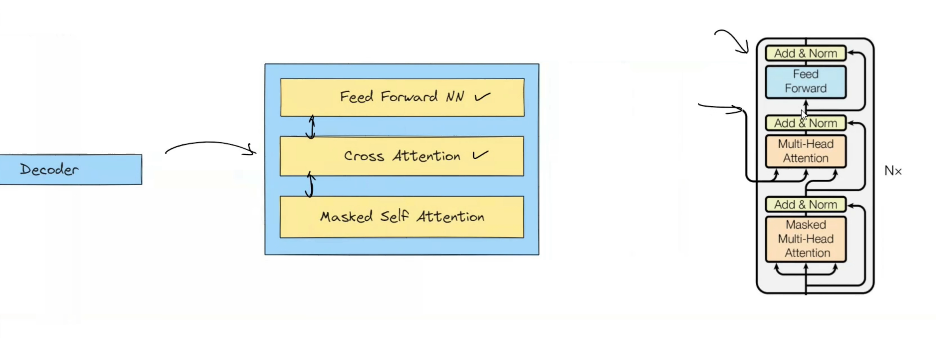

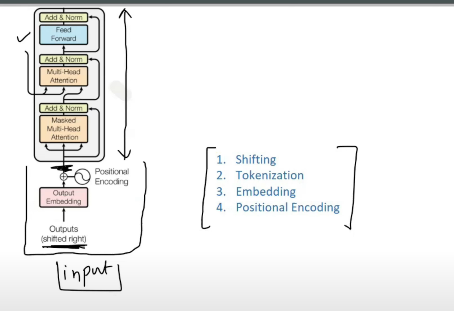

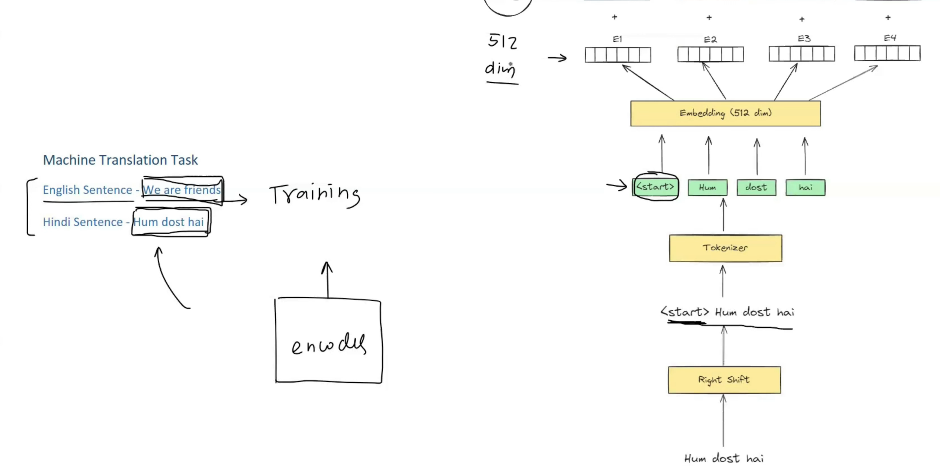

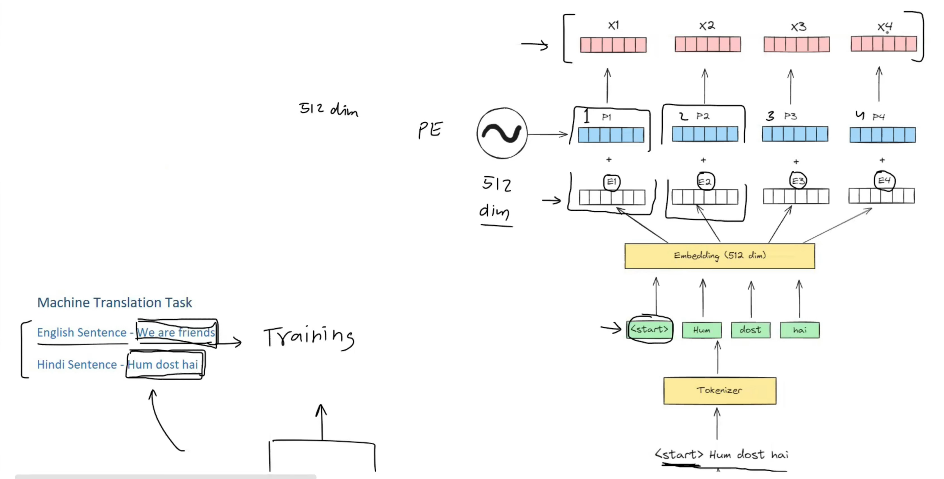

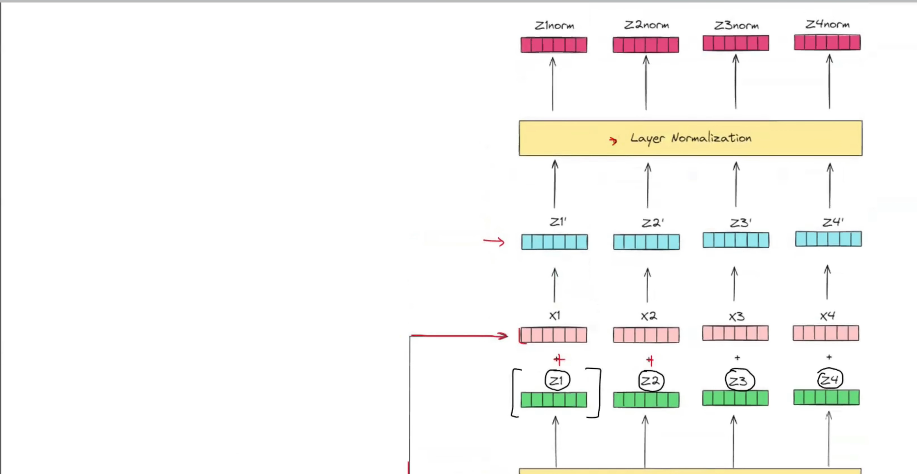

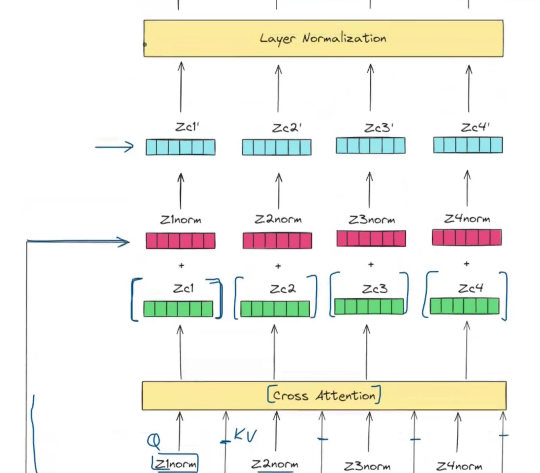

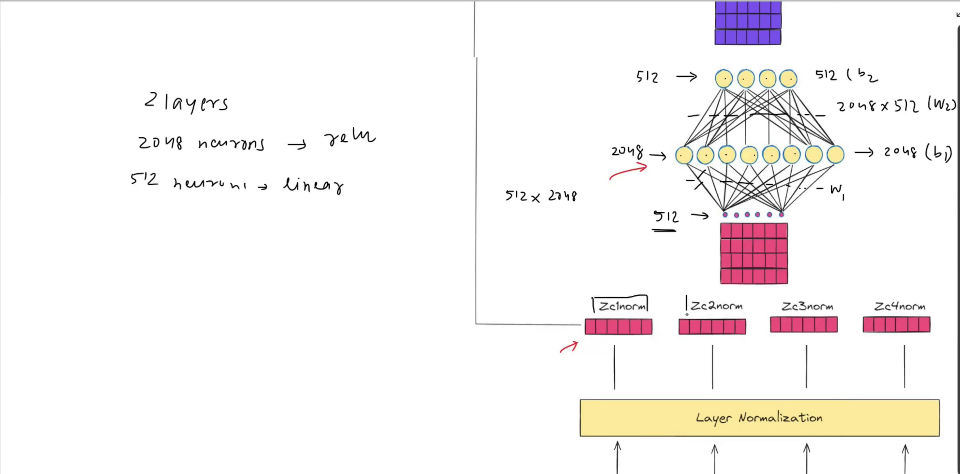

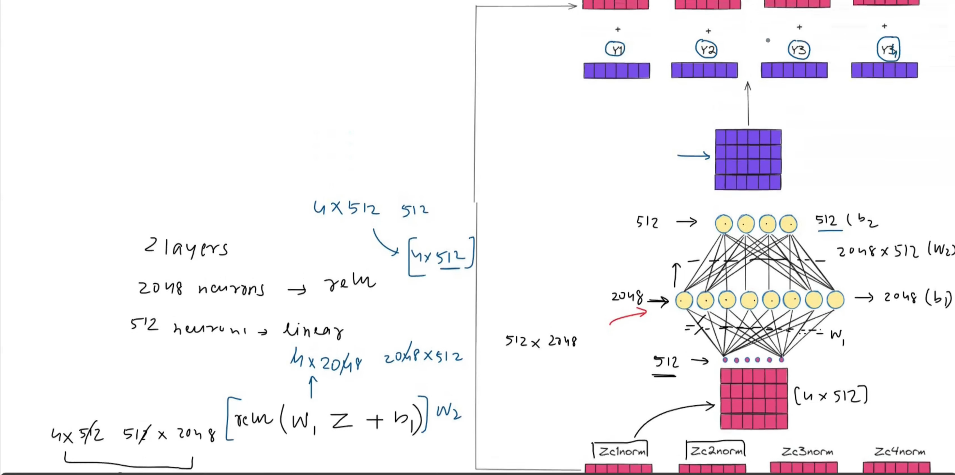

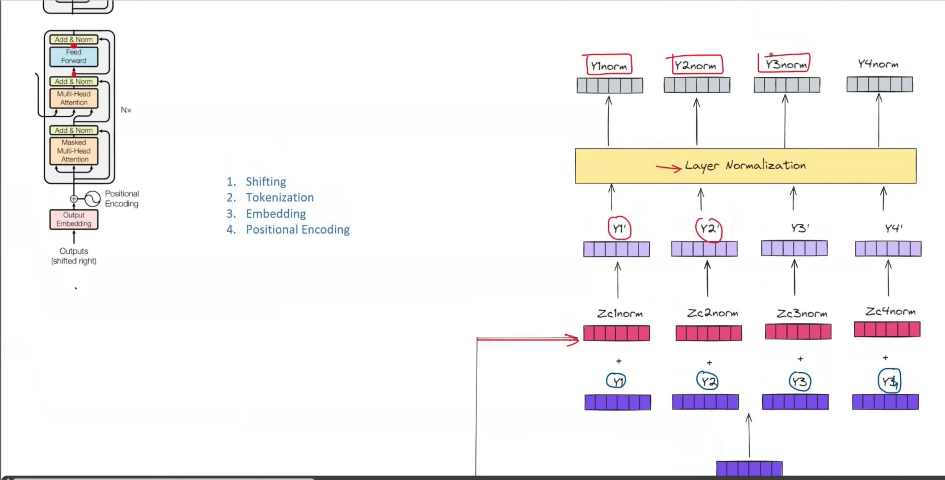

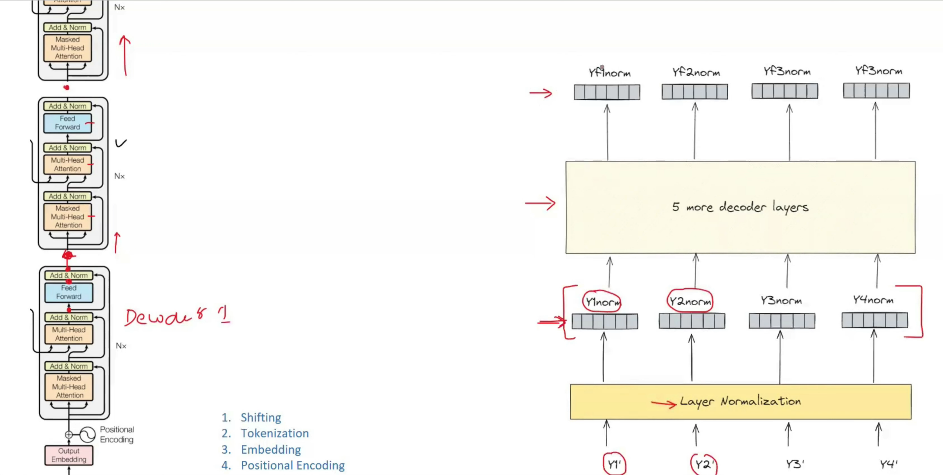

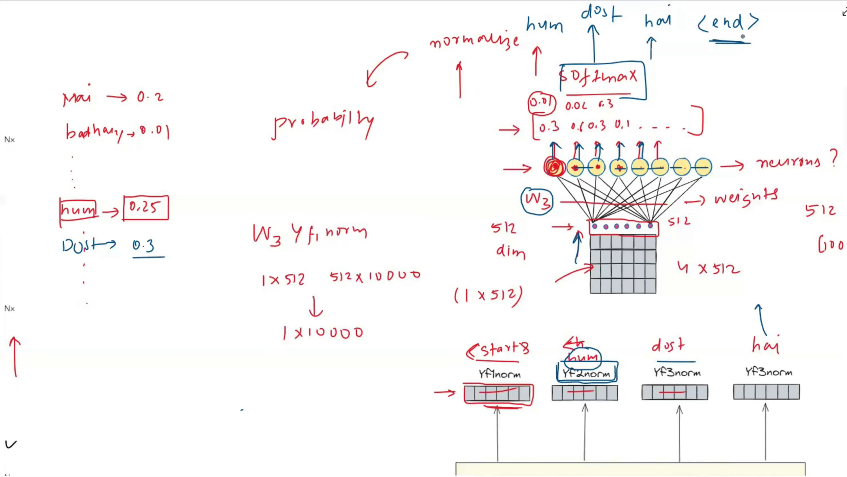

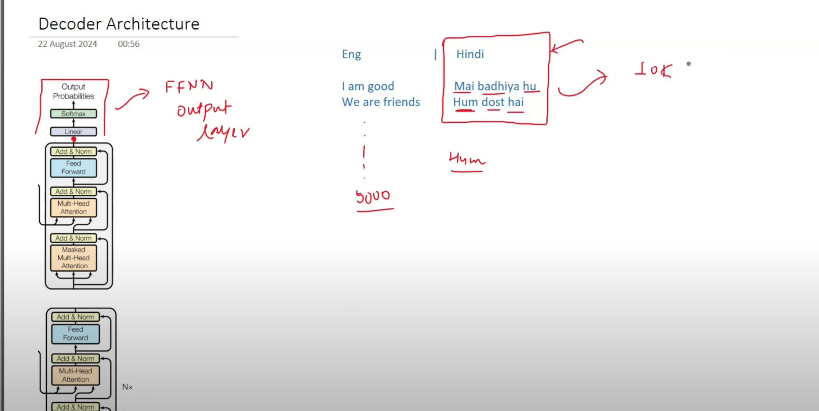

The decoder architecture, particularly during the training phase, is a crucial component of the Transformer model, designed to translate encoded input into a coherent output sequence.

### Best Summary of Decoder Architecture

The Transformer can be seen as a box containing two main components: an **encoder** and a **decoder**. The encoder processes the input sentence, while the **decoder** takes the encoder's output and generates the target output sentence.

The decoder itself is not a single unit but a **stack of six identical decoder blocks**. Each of these individual decoder blocks consists of three primary sub-blocks:
1.  **Masked Multi-Head Self-Attention**: Processes the decoder's input sequence, ensuring that future tokens are not considered when predicting the current token.
2.  **Cross-Attention (or Encoder-Decoder Attention)**: Connects the decoder with the encoder by allowing the decoder to attend to the encoder's output. This step enables the model to find similarities between the input (e.g., English) and output (e.g., Hindi) sentences.
3.  **Feed-Forward Neural Network (FFNN)**: Applies non-linear transformations to the data.

After processing through all six decoder blocks, a final **output block** (composed of a Linear layer and a Softmax layer) translates the numerical representations into a probability distribution over the target vocabulary, allowing the model to predict the next word in the output sequence. This entire process, as described, focuses on how the decoder behaves during **training**, where it operates in a non-autoregressive manner, unlike during inference.

### Stepwise Process in Decoder Architecture (Training Perspective)

The decoder's operation can be broken down into three main parts: input preparation, processing within a single decoder block, and the final output block. An example of English to Hindi machine translation is used to illustrate the process.

#### 1. Input Preparation (Input Block Processing)
This initial phase prepares the target output sentence (e.g., Hindi sentence "हम दोस्त हैं") for the first decoder block. It involves four key operations:
*   **Shift Right**: A special **"start" token** is added to the beginning of the output sentence. This signals the initiation of the training process for the decoder. So, "हम दोस्त हैं" becomes "start हम दोस्त हैं".
*   **Tokenization**: The shifted sentence is then broken down into individual **tokens** (words). For "start हम दोस्त हैं," this would result in four tokens: "start," "हम," "दोस्त," and "हैं".
*   **Embedding**: Each token is converted into a **numerical vector** (e.g., 512 dimensions). These vectors, like e1 for "start" and e2 for "हम," allow the machine to understand and process the words.
*   **Positional Encoding**: To account for the order of words, a unique **positional encoding vector** (also 512 dimensions) is generated for each position in the sequence (e.g., for position 1, 2, 3, 4). This positional vector is then **added** to the corresponding word's embedding vector. The resulting combined vectors (x1, x2, x3, x4) are the final input to the first decoder block, containing both semantic and positional information.

#### 2. Processing within a Single Decoder Block
All six decoder blocks are identical in architecture, so understanding one explains them all. Each block takes input vectors (e.g., x1, x2, x3, x4 for the first block) and processes them through three main sub-blocks, with "Add & Normalize" steps in between.

*   **Masked Multi-Head Self-Attention**:
    *   **Function**: Similar to a normal multi-head attention mechanism but with a crucial difference: **masking**. When generating a contextual embedding (e.g., z2 for "हम"), the model is only allowed to "see" the current token and all preceding tokens ("start" and "हम"), but **not any subsequent tokens** ("दोस्त" and "हैं"). This prevents the model from looking ahead in the output sequence during training.
    *   **Output**: Contextual embedding vectors (z1, z2, z3, z4) for each token.
*   **Add & Normalize (Layer Normalization)**:
    *   **Function**: The output vectors from the Masked Multi-Head Self-Attention (z1-z4) are **added** to the original input vectors (x1-x4) via a **residual (or skip) connection**. This sum then undergoes **Layer Normalization**.
    *   **Purpose**: This step helps to **stabilize the training process** by ensuring that the numerical values in the vectors remain within a manageable range, preventing issues like exploding or vanishing gradients.
*   **Cross-Attention (Encoder-Decoder Attention)**:
    *   **Input**: This block receives **two main inputs**:
        1.  **Query (Q) vectors**: These come from the normalized output of the *previous* "Add & Normalize" step within the decoder (e.g., z1' norm, z2' norm, etc.).
        2.  **Key (K) and Value (V) vectors**: These come from the **final output of the encoder** (the processed English sentence embeddings).
    *   **Function**: This is where the decoder can **attend to the information from the encoder**. It calculates similarity scores between the tokens in the target sequence (Hindi) and the tokens in the source sequence (English).
    *   **Output**: New contextual embedding vectors (zc1, zc2, zc3, zc4) that combine information from both the English and Hindi sentences.
*   **Add & Normalize (Layer Normalization)**:
    *   **Function**: The output from the Cross-Attention (zc1-zc4) is **added** to the output from the *previous* "Add & Normalize" step (z1' norm, etc.) using another residual connection. This sum is then **layer normalized**.
    *   **Purpose**: Further stabilizes the training process.
*   **Feed-Forward Neural Network (FFNN)**:
    *   **Architecture**: This sub-block consists of two fully connected layers. The first layer expands the dimensionality of the vectors (e.g., from 512 to 2048 neurons) and applies a **ReLU activation function**. The second layer reduces the dimensionality back to the original size (e.g., 2048 to 512 neurons) using a **linear activation**.
    *   **Purpose**: Introduces **non-linearity** into the model, allowing it to capture more complex patterns and relationships in the data.
    *   **Output**: Transformed vectors (y1, y2, y3, y4).
*   **Add & Normalize (Layer Normalization)**:
    *   **Function**: The output from the FFNN (y1-y4) is **added** to the output from the *previous* "Add & Normalize" step (zc1' norm, etc.) via a final residual connection. This sum is then **layer normalized**.
    *   **Output**: The final normalized vectors (y1 norm, y2 norm, y3 norm, y4 norm) that represent the output of a single decoder block.

#### 3. Stacking of Decoder Blocks and Final Output
The process described above for a single decoder block is repeated six times.
*   The **output of the first decoder block** (y1 norm, y2 norm, etc.) becomes the **input for the second decoder block**, and so on, until the data has passed through all **six decoder blocks**.
*   While the architecture of each block is identical, the **parameters (weights and biases) within each block are unique**.
*   **Output Block (Final Prediction)**:
    *   **Input**: The final normalized vectors (yf1 norm, yf2 norm, yf3 norm, etc.) from the sixth and last decoder block.
    *   **Linear Layer**: This layer has a number of neurons equal to the **vocabulary size (V)** of the target language (e.g., all unique Hindi words in the dataset, which might be 10,000). Each neuron corresponds to a unique word in the vocabulary.
    *   **Softmax Layer**: The output of the linear layer (raw scores for each vocabulary word) is passed through a **Softmax activation function**.
    *   **Prediction**: Softmax converts these raw scores into a **probability distribution** where each number represents the likelihood of a specific word being the correct output. For each token, the word with the **highest probability** is chosen as the predicted output word. For instance, if the probability for "हम" is highest, then "हम" is predicted.

This entire stepwise process allows the decoder to systematically generate contextualized embeddings for the target sequence, integrate information from the source sequence, and finally predict the output words during the training of the Transformer model.



---

# 🔑 Transformer Decoder Architecture Q\&A

### **1. What is a Transformer Decoder?**

A Transformer decoder is the part of the Transformer architecture designed for *auto-regressive sequence generation*.
It takes in a sequence of tokens (text, audio frames, etc.) and predicts the **next token** step by step.

---

### **2. How is the Decoder different from the Encoder?**

* **Encoder**: Processes the full input sequence in parallel (used in translation, classification, etc.).
* **Decoder**: Generates output tokens **one at a time**, while attending to past tokens and (optionally) encoder outputs.

Key differences:

* Decoder has an **extra causal mask** to prevent "cheating" by looking at future tokens.
* Decoder may include **cross-attention** (in encoder–decoder models like translation).

---

### **3. What are the main components of a Transformer Decoder block?**

Each decoder block has:

1. **Masked Multi-Head Self-Attention (MHA)**

   * Lets the model attend to **previous tokens only** (causal masking).
   * Ensures predictions are sequential.

2. **Cross-Attention (optional)**

   * Present in encoder–decoder models.
   * Lets the decoder attend to encoder outputs (useful for tasks like translation).
   * Absent in GPT-style models.

3. **Feed-Forward Network (FFN)**

   * Position-wise fully connected layers that add non-linearity.

4. **Residual Connections + Layer Normalization**

   * Stabilize training and improve gradient flow.

---

### **4. What is Masked Self-Attention?**

* Self-attention compares every token with every other token in the sequence.
* In the decoder, we use a **causal mask** (triangular matrix) so position *t* can only attend to tokens at positions ≤ *t*.
* This prevents future leakage during generation.

---

### **5. How does Multi-Head Attention work inside the decoder?**

* Each attention head projects inputs into Query (Q), Key (K), and Value (V) vectors.
* Attention score = `softmax(QKᵀ / √d_k) V`
* Multiple heads allow the model to attend to different relationships simultaneously.
* Outputs of heads are concatenated and projected.

---

### **6. What’s the role of the Feed-Forward Network (FFN)?**

* Two linear layers with a nonlinearity (usually ReLU or GELU).
* Expands dimensionality (e.g., from *d\_model* → 4*d\_model* → *d\_model*).
* Helps model complex transformations.

---

### **7. Where do residuals and normalization come in?**

* After each sublayer (attention or FFN), the input is added back (residual).
* Layer normalization is applied (either pre- or post-residual, depending on variant).
* Helps prevent vanishing gradients.

---

### **8. How do stacked decoder blocks form the full decoder?**

* Multiple decoder layers (e.g., 12, 24, 96 depending on model size).
* Output flows through each block sequentially.
* Final layer produces hidden states that are projected onto the vocabulary for prediction.

---

### **9. What about embeddings and positional encoding?**

* Input tokens are embedded into vectors (*d\_model* dimension).
* Since attention is permutation-invariant, we add **positional encodings** (sinusoidal or learned).
* This lets the model understand sequence order.

---

### **10. How does the decoder generate text in practice?**

1. Start with a special **start token** (`<bos>`).
2. Pass through embeddings + decoder blocks.
3. Softmax over vocabulary → pick next token.
4. Append token to sequence and repeat until stop token (`<eos>`) or max length.

---

### **11. How is the Transformer Decoder trained?**

* Uses **teacher forcing**:
  At step *t*, the model sees the ground-truth previous tokens instead of its own predictions.
* Loss: **cross-entropy** between predicted distribution and ground truth token.
* Optimizer: Usually AdamW with learning rate warmup + cosine decay.

---

### **12. What are real-world variants of Transformer Decoders?**

* **GPT (Generative Pretrained Transformer)** → decoder-only, massive scaling.
* **BART / T5** → encoder-decoder, decoder uses cross-attention.
* **OPT, LLaMA, Falcon, Mistral** → decoder-only with tweaks in architecture/efficiency.

---


